# Random Forest Classification: Predicting Water Source Condition

This notebook builds a **Random Forest classifier** to predict whether a water
source is *dried* or *active*, based on geographic, topographic, and climate
features (elevation, aspect, slope, road proximity by direction, and
temperature/precipitation/evaporation/dewpoint statistics).

The notebook walks through the full machine learning workflow step by step:

1. **Load & inspect the raw data**
2. **Select relevant features**
3. **Clean & encode categorical variables**
4. **Prepare features (X) and target (y)**
5. **Split into train/test sets**
6. **Build a preprocessing + model pipeline**
7. **Train the Random Forest**
8. **Evaluate performance** (accuracy, precision, recall, F1, ROC-AUC, confusion matrix, ROC curve)
9. **Cross-validate** for a more robust performance estimate
10. **Inspect feature importance** to understand which variables drive predictions

Each section below has a short explanation of *what* is being done and *why*,
so that the notebook is easy to follow and adapt to other datasets.

> **Note:** This notebook expects a CSV file named `Full_Analysis_data.csv`
> in the working directory (same format as the original analysis). Update
> the file path in the "Load Data" section if your file is named or located
> differently.

## 1. Import Core Libraries

We start by importing `pandas` and `numpy` for data handling. Additional
libraries (scikit-learn, matplotlib, seaborn) are imported later, right
before they are first used, so it's clear which section needs them.

In [1]:
import pandas as pd
import numpy as np

## 2. Load the Raw Data

We read the CSV file into a pandas DataFrame. The `.iloc[:, 1:]` drops the
first column — typically an unnamed index column that pandas/Excel exports
often add — since it carries no predictive information.

In [2]:
import os

DATA_CSV_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "Full_Analysis_data.csv"))
data = pd.read_csv(DATA_CSV_PATH).iloc[:, 1:]

# Quick look at the raw data
print("Shape of raw data:", data.shape)
data.head()

Shape of raw data: (3287, 38)


,Latitude,Longitude,Perennial / Seasonal,Dried since how many years?,Source Condition,Elev,Aspect,geometry,Formation,Rocktypes,...,Slope_cos,LU,Dewpoint_rate,Temperature_rate,Precipitation_rate,Evaporation_rate,Dewpoint_mean,Temperature_mean,Precipitation_mean,Evaporation_mean
0,27.556629,85.596365,perennial,NaN,active,1638.0,248.687530,POINT (361422.324611507 3048874.854799143),Formation II,"Banded gneiss, marble",...,0.000027,"[7, 7, 7, 7, 7, 4, 4, 4, 4, 4, 7, 7, 7, 7, 7, ...",0.038090,0.041817,24.755398,0.000015,12.998818,17.667891,2577.153037,-0.003904
1,27.565024,85.638463,perennial,2017.0,dried,1218.0,123.929794,POINT (365589.2869813394 3049758.535742284),Formation II,"Banded gneiss, marble",...,0.000098,"[7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, ...",0.013289,0.026505,16.348608,-0.000002,12.944189,17.668510,2496.272664,-0.004054
2,27.544086,85.569624,perennial,NaN,active,1425.0,213.076830,POINT (358765.9169889486 3047515.4057141286),Formation II,"Banded gneiss, marble",...,0.000018,"[4, 4, 4, 4, 4, 7, 7, 7, 7, 7, 4, 4, 4, 4, 4, ...",0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627
3,27.545604,85.570672,perennial,NaN,active,1483.0,261.869900,POINT (358871.3259907726 3047682.402644412),Formation II,"Banded gneiss, marble",...,0.000070,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627
4,27.545577,85.570475,perennial,NaN,active,1483.0,261.869900,POINT (358851.8899854751 3047679.6219697036),Formation II,"Banded gneiss, marble",...,0.000070,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 7, ...",0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627


It's good practice to inspect column names and data types before
proceeding, to catch typos, unexpected types, or missing-value issues
early.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Latitude                     3287 non-null   float64
 1   Longitude                    3287 non-null   float64
 2   Perennial / Seasonal         3287 non-null   str    
 3   Dried since how many years?  723 non-null    float64
 4   Source Condition             3287 non-null   str    
 5   Elev                         3287 non-null   float64
 6   Aspect                       3287 non-null   float64
 7   geometry                     3287 non-null   str    
 8   Formation                    3261 non-null   str    
 9   Rocktypes                    3271 non-null   str    
 10  buffer                       3287 non-null   str    
 11  Road-N                       3287 non-null   int64  
 12  Road-NE                      3287 non-null   int64  
 13  Road-E                       

## 3. Select the Relevant Features

Not every column in the raw dataset is needed for modeling. Here we select
the subset of columns that are relevant predictors (topography, road
direction indicators, aspect indicators, slope trigonometric transforms, and
climate rate/mean statistics), plus the two categorical columns
(`Perennial / Seasonal` and `Source Condition`) that need to be encoded.

In [4]:
maindata = data[[
    'Perennial / Seasonal', 'Source Condition', 'Elev', 'Aspect',
    'Road-N', 'Road-NE', 'Road-E', 'Road-SE', 'Road-S', 'Road-SW', 'Road-W', 'Road-NW',
    'Aspect-E', 'Aspect-NE', 'Aspect-N', 'Aspect-NW', 'Aspect-W',
    'Aspect-SW', 'Aspect-S', 'Aspect-SE',
    'Slope_sin', 'Slope_cos',
    'Dewpoint_rate', 'Temperature_rate', 'Precipitation_rate', 'Evaporation_rate',
    'Dewpoint_mean', 'Temperature_mean', 'Precipitation_mean', 'Evaporation_mean'
]]

maindata.head()

,Perennial / Seasonal,Source Condition,Elev,Aspect,Road-N,Road-NE,Road-E,Road-SE,Road-S,Road-SW,...,Slope_sin,Slope_cos,Dewpoint_rate,Temperature_rate,Precipitation_rate,Evaporation_rate,Dewpoint_mean,Temperature_mean,Precipitation_mean,Evaporation_mean
0,perennial,active,1638.0,248.687530,0,0,1,1,1,0,...,1.0,0.000027,0.038090,0.041817,24.755398,0.000015,12.998818,17.667891,2577.153037,-0.003904
1,perennial,dried,1218.0,123.929794,3,2,3,1,1,1,...,1.0,0.000098,0.013289,0.026505,16.348608,-0.000002,12.944189,17.668510,2496.272664,-0.004054
2,perennial,active,1425.0,213.076830,0,1,1,0,0,0,...,1.0,0.000018,0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627
3,perennial,active,1483.0,261.869900,0,1,1,0,0,0,...,1.0,0.000070,0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627
4,perennial,active,1483.0,261.869900,0,1,1,0,0,0,...,1.0,0.000070,0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627


## 4. Encode Categorical Columns Manually

Two columns are text/categorical and need to be converted to numeric form
before modeling:

- **`Perennial / Seasonal`** → `1` if the source is `perennial`, else `0`
- **`Source Condition`** → `1` if the source is `dried`, else `0`

We define small helper functions and apply them with `.map()`. This gives us
full control over the exact mapping (as opposed to automatic encoders, which
might assign labels in an unexpected order).

In [5]:
def map_perennial_seasonal(s):
    """Map 'perennial' -> 1, anything else (e.g. 'seasonal') -> 0."""
    if s == 'perennial':
        return 1
    else:
        return 0

def map_source_condition(s):
    """Map 'dried' -> 1, anything else (e.g. 'active') -> 0."""
    if s == 'dried':
        return 1
    else:
        return 0

In [6]:
maindata["Perennial / Seasonal"] = maindata["Perennial / Seasonal"].map(map_perennial_seasonal)
maindata["Source Condition"] = maindata["Source Condition"].map(map_source_condition)

maindata[["Perennial / Seasonal", "Source Condition"]].head()

,Perennial / Seasonal,Source Condition
0,1,0
1,1,1
2,1,0
3,1,0
4,1,0


## 5. Ensure Consistent Numeric Type

All modeling algorithms in scikit-learn require numeric input. We cast the
entire DataFrame to `float` to make sure every column (including the ones
we just mapped) is numeric and consistent.

In [7]:
maindata = maindata.astype(float)
maindata.dtypes

Perennial / Seasonal    float64
Source Condition        float64
Elev                    float64
Aspect                  float64
Road-N                  float64
Road-NE                 float64
Road-E                  float64
Road-SE                 float64
Road-S                  float64
Road-SW                 float64
Road-W                  float64
Road-NW                 float64
Aspect-E                float64
Aspect-NE               float64
Aspect-N                float64
Aspect-NW               float64
Aspect-W                float64
Aspect-SW               float64
Aspect-S                float64
Aspect-SE               float64
Slope_sin               float64
Slope_cos               float64
Dewpoint_rate           float64
Temperature_rate        float64
Precipitation_rate      float64
Evaporation_rate        float64
Dewpoint_mean           float64
Temperature_mean        float64
Precipitation_mean      float64
Evaporation_mean        float64
dtype: object

## 6. Drop Missing Values

Random Forest (like most scikit-learn estimators) cannot handle `NaN`
values directly. Here we take the simplest approach — drop any row with a
missing value — and reset the index afterward so it's clean and contiguous.

> **Tip:** For datasets with a lot of missingness, consider imputation
> (e.g. `SimpleImputer`) instead of dropping rows, to avoid losing too much
> data.

In [8]:
print("Rows before dropping missing values:", len(maindata))

maindata = maindata.dropna().reset_index().iloc[:, 1:]

print("Rows after dropping missing values:", len(maindata))
maindata.head()

Rows before dropping missing values: 3287
Rows after dropping missing values: 3285


,Perennial / Seasonal,Source Condition,Elev,Aspect,Road-N,Road-NE,Road-E,Road-SE,Road-S,Road-SW,...,Slope_sin,Slope_cos,Dewpoint_rate,Temperature_rate,Precipitation_rate,Evaporation_rate,Dewpoint_mean,Temperature_mean,Precipitation_mean,Evaporation_mean
0,1.0,0.0,1638.0,248.687530,0.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.000027,0.038090,0.041817,24.755398,0.000015,12.998818,17.667891,2577.153037,-0.003904
1,1.0,1.0,1218.0,123.929794,3.0,2.0,3.0,1.0,1.0,1.0,...,1.0,0.000098,0.013289,0.026505,16.348608,-0.000002,12.944189,17.668510,2496.272664,-0.004054
2,1.0,0.0,1425.0,213.076830,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.000018,0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627
3,1.0,0.0,1483.0,261.869900,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.000070,0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627
4,1.0,0.0,1483.0,261.869900,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.000070,0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627


## 7. Import Modeling Libraries

Now that the data is clean, we bring in the full modeling toolkit:

- **`train_test_split`, `cross_val_score`** — splitting data and cross-validation
- **`StandardScaler`, `LabelEncoder`** — preprocessing
- **`Pipeline`** — chains preprocessing + model into a single reusable object
- **Metrics** — accuracy, precision, recall, F1, confusion matrix, classification report, ROC-AUC, ROC curve
- **`RandomForestClassifier`** — the model itself
- **`matplotlib`, `seaborn`** — visualization

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 8. Encode the Target Variable

Although `Source Condition` was already mapped to `0`/`1` manually above,
we pass it through a `LabelEncoder` as well. This is a common defensive
step: it guarantees the target is in the exact numeric format scikit-learn
expects, and `le.classes_` gives us a human-readable record of which
original label corresponds to which encoded value (useful later for
labeling the confusion matrix).

In [10]:
le = LabelEncoder()
maindata["Source Condition"] = le.fit_transform(maindata["Source Condition"])

print("Classes found by LabelEncoder:", le.classes_)
print("(Index 0 ->", le.classes_[0], ", Index 1 ->", le.classes_[1], ")")

Classes found by LabelEncoder: [0. 1.]
(Index 0 -> 0.0 , Index 1 -> 1.0 )


## 9. Define Features (X) and Target (y)

- **`X`** — all columns except the target, cast to integer type
- **`y`** — the target column (`Source Condition`)

We also apply `pd.get_dummies()` to `X` as a safeguard in case any remaining
categorical/object columns are present — `drop_first=True` avoids the
"dummy variable trap" (perfect multicollinearity between dummy columns).

In [11]:
X = maindata.drop(columns=["Source Condition"]).astype(int)
y = maindata["Source Condition"]

# One-hot encode any remaining categorical predictors (safe no-op if none exist)
X = pd.get_dummies(X, drop_first=True)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
X.head()

Feature matrix shape: (3285, 29)
Target vector shape: (3285,)


,Perennial / Seasonal,Elev,Aspect,Road-N,Road-NE,Road-E,Road-SE,Road-S,Road-SW,Road-W,...,Slope_sin,Slope_cos,Dewpoint_rate,Temperature_rate,Precipitation_rate,Evaporation_rate,Dewpoint_mean,Temperature_mean,Precipitation_mean,Evaporation_mean
0,1,1638,248,0,0,1,1,1,0,0,...,1,0,0,0,24,0,12,17,2577,0
1,1,1218,123,3,2,3,1,1,1,1,...,1,0,0,0,16,0,12,17,2496,0
2,1,1425,213,0,1,1,0,0,0,0,...,1,0,0,0,19,0,11,16,2575,0
3,1,1483,261,0,1,1,0,0,0,0,...,1,0,0,0,19,0,11,16,2575,0
4,1,1483,261,0,1,1,0,0,0,0,...,1,0,0,0,19,0,11,16,2575,0


## 10. Train/Test Split

We hold out **30%** of the data for testing, using `stratify=y` to preserve
the same class balance (dried vs. active) in both the training and test
sets. `random_state=42` makes the split reproducible.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass balance in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass balance in test set:")
print(y_test.value_counts(normalize=True))

Training set size: 2299
Test set size: 986

Class balance in training set:
Source Condition
0    0.779469
1    0.220531
Name: proportion, dtype: float64

Class balance in test set:
Source Condition
0    0.778905
1    0.221095
Name: proportion, dtype: float64


## 11. Build the Modeling Pipeline

We wrap preprocessing and the classifier into a single `Pipeline`:

1. **`StandardScaler(with_mean=False)`** — scales features to unit variance.
   `with_mean=False` keeps the transform safe for sparse matrices (relevant
   if `get_dummies` produced a sparse output), though it also works fine on
   dense data.
2. **`RandomForestClassifier`** — an ensemble of decision trees.
   - `n_estimators=2000` — number of trees in the forest (more trees →
     more stable predictions, at the cost of compute time)
   - `class_weight="balanced"` — automatically re-weights classes inversely
     proportional to their frequency, which helps when "dried" vs "active"
     sources are not evenly represented
   - `random_state=42` — reproducibility

Wrapping everything in a `Pipeline` means the same `fit`/`predict` calls
apply the scaler and the model together, which prevents data leakage and
keeps the workflow tidy (e.g. for cross-validation later).

In [13]:
pipeline = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", RandomForestClassifier(
        n_estimators=2000,
        random_state=42,
        class_weight="balanced"
    ))
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",2000
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every tr

## 12. Train the Model

Fitting the pipeline on the training data scales the features and trains
all 2000 trees of the Random Forest in one call.

In [14]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['Perennial / Seasonal','Elev','Aspect',...,'Temperature_mean', 'Precipitation_mean','Evaporation_mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 13. Generate Predictions

We generate two kinds of predictions on the held-out test set:

- **`y_pred`** — the predicted class label (0 or 1)
- **`y_prob`** — the predicted probability of the positive class (used for
  ROC-AUC and the ROC curve, which need a continuous score rather than a
  hard label)

In [15]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

## 14. Evaluate Performance

We compute the standard classification metrics:

| Metric | What it tells us |
|---|---|
| **Accuracy** | Overall fraction of correct predictions |
| **Precision** | Of predicted "dried" sources, how many actually were |
| **Recall** | Of actual "dried" sources, how many we correctly caught |
| **F1 Score** | Harmonic mean of precision and recall (balances both) |
| **ROC-AUC** | Model's ability to rank positive cases above negative ones, across all thresholds |

The full `classification_report` also breaks these down per class.

In [16]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC-AUC:  ", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:  0.9888438133874239
Precision: 0.9519650655021834
Recall:    1.0
F1 Score:  0.9753914988814317
ROC-AUC:   0.9999104071100917

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       768
           1       0.95      1.00      0.98       218

    accuracy                           0.99       986
   macro avg       0.98      0.99      0.98       986
weighted avg       0.99      0.99      0.99       986



### Confusion Matrix

The confusion matrix shows the counts of correct and incorrect predictions
broken down by actual vs. predicted class, which is often more informative
than a single accuracy number — especially with imbalanced classes.

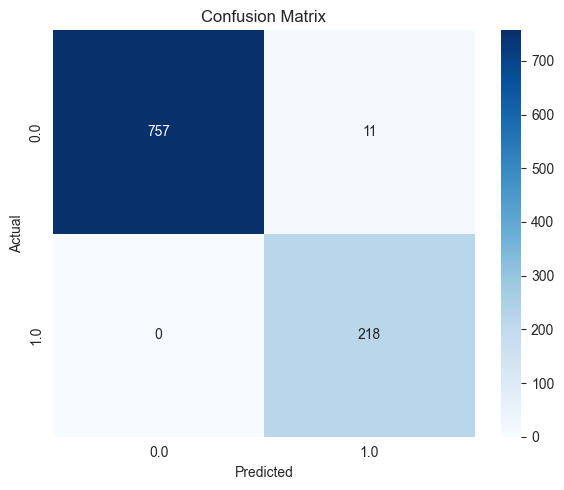

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("model1_exploratory_confusion_matrix.png", dpi=300)
plt.show()

### ROC Curve

The ROC (Receiver Operating Characteristic) curve plots the true positive
rate against the false positive rate at every possible classification
threshold. A curve that hugs the top-left corner (AUC close to 1.0)
indicates strong discriminative ability; a diagonal line (AUC = 0.5)
indicates no better than random guessing.

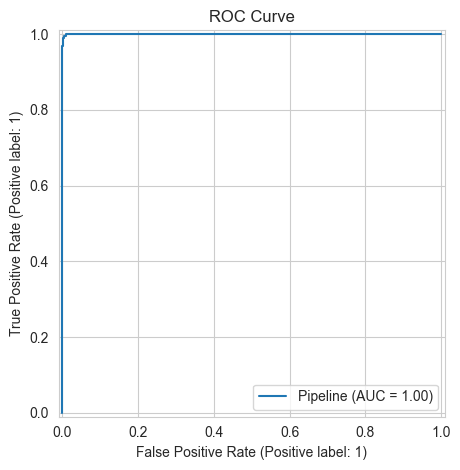

In [18]:
RocCurveDisplay.from_estimator(pipeline, X_test, y_test)
plt.title("ROC Curve")
plt.tight_layout()
plt.savefig("model1_exploratory_roc_curve.png", dpi=300)
plt.show()

## 15. Cross-Validation

A single train/test split can be sensitive to how the data happened to be
divided. **5-fold cross-validation** trains and evaluates the model 5 times
on different splits of the *full* dataset (`X`, `y`) and reports the F1
score each time, giving a more robust estimate of how well the model
generalizes.

In [19]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1")

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1:", np.mean(cv_scores))
print("Std  CV F1:", np.std(cv_scores))

Cross-validation F1 scores: [0.96503497 0.92903226 0.98976109 0.97887324 0.82857143]
Mean CV F1: 0.93825459665154
Std  CV F1: 0.058541319151703415


## 16. Feature Importance

Random Forests provide a built-in measure of **feature importance** — how
much each feature, on average, reduces impurity across all trees in the
forest. This helps identify which environmental and geographic variables
are most predictive of whether a water source dries up.

We extract the importances from the trained classifier (`pipeline.named_steps["clf"]`),
pair them with their feature names, and sort from most to least important.

In [20]:
importances = pipeline.named_steps["clf"].feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp.head(15))

                 Feature  Importance
27    Precipitation_mean    0.375581
23    Precipitation_rate    0.312044
0   Perennial / Seasonal    0.068223
1                   Elev    0.047984
26      Temperature_mean    0.047017
25         Dewpoint_mean    0.038805
2                 Aspect    0.036610
3                 Road-N    0.007373
4                Road-NE    0.007300
5                 Road-E    0.006514
6                Road-SE    0.005954
7                 Road-S    0.005567
9                 Road-W    0.005453
15              Aspect-W    0.005346
10               Road-NW    0.005319


The bar chart below visualizes the top 15 most important features,
making it easy to see at a glance which variables the model relies on
most.

C:\Users\kants\AppData\Local\Temp\ipykernel_20508\3295079710.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15), palette="viridis")


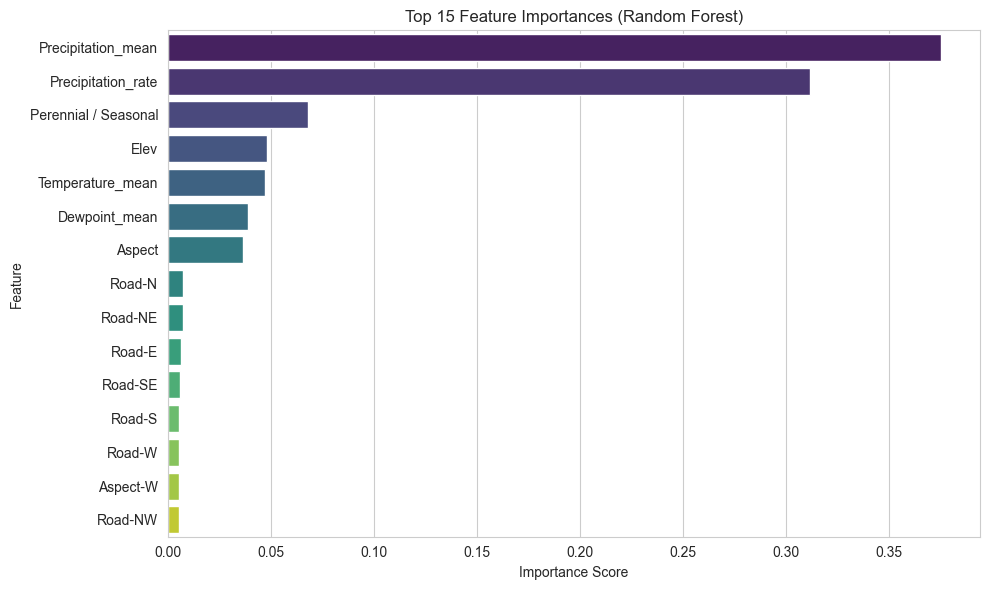

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15), palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("model1_exploratory_feature_importance.png", dpi=300)
plt.show()

## 17. Summary & Next Steps

This notebook demonstrated an end-to-end Random Forest classification
workflow:

- Loaded and cleaned the dataset, encoding categorical variables manually
- Built a `StandardScaler` + `RandomForestClassifier` pipeline
- Evaluated the model with accuracy, precision, recall, F1, ROC-AUC, a
  confusion matrix, and an ROC curve
- Validated robustness with 5-fold cross-validation
- Identified the most influential features driving predictions

**Possible next steps:**
- Tune hyperparameters (`n_estimators`, `max_depth`, `min_samples_leaf`, etc.)
  with `GridSearchCV` or `RandomizedSearchCV`
- Compare against other models (Gradient Boosting, Logistic Regression, SVM)
- Investigate the top features further (e.g. partial dependence plots)
- If missing data is substantial, consider imputation instead of dropping rows